## Portfolio archive and evaluation note

This notebook is retained as part of the original MRI denoising experiment suite. Saved cells and outputs are included so the development work can be reviewed without rerunning long GPU training jobs.

> **Evaluation limitation:** In the supplied workflow, several experiments use the same image directory for both training and validation. The stored metrics are therefore historical development results, not independently reproduced estimates from a held-out validation set. A reliable rerun should use patient-level train, validation, and test splits.

The code was developed in Google Colab and contains hard-coded paths under `/content/drive/MyDrive/Final RI/`. Update those paths before running it with your own dataset.


In [ ]:
# ===========================
#  Cell 1: Rician-Only Noise with Logging
# ===========================
import os, cv2, numpy as np, glob, random, zipfile, pandas as pd
from tqdm import tqdm
from google.colab import drive

# --- 1. Mount Google Drive for data access ---
drive.mount('/content/drive')

# --- 2. Extract dataset if not already extracted ---
zip_path = "/content/drive/MyDrive/Final RI/glioma.zip"
extract_path = "/content/drive/MyDrive/Final RI/glioma"
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(" Extracted glioma.zip to:", extract_path)
else:
    print(" glioma/ already exists. Skipping extraction.")

# --- 3. Define clean and Rician-noisy image directories ---
CLEAN_DIR = extract_path
NOISY_DIR = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_dwt_rician_0.03"
os.makedirs(NOISY_DIR, exist_ok=True)

# --- 4. Set random seeds for reproducibility ---
random.seed(42)
np.random.seed(42)

# --- 5. Define Rician noise function ---
def safe_clip(img):
    return np.clip(img, 1e-6, 1.0)

def add_rician_noise(img, sigma=0.03):
    noise_real = np.random.normal(0, sigma, img.shape)
    noise_imag = np.random.normal(0, sigma, img.shape)
    return safe_clip(np.sqrt((img + noise_real)**2 + noise_imag**2))

# --- 6. Generate and save Rician-noised versions of all images ---
image_paths = sorted(glob.glob(os.path.join(CLEAN_DIR, "*.*")))
log_data = []

print(f" Found {len(image_paths)} clean images to process")

for img_path in tqdm(image_paths, desc=" Adding Rician noise to all images"):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f" Skipping unreadable file: {img_path}")
        continue

    img = cv2.resize(img, (256, 256)).astype(np.float32) / 255.0

    #  Apply Rician noise only
    img_noisy = add_rician_noise(img, sigma=0.03)
    noise_types = ["Rician"]

    out_path = os.path.join(NOISY_DIR, os.path.basename(img_path))
    img_save = (img_noisy * 255).astype(np.uint8)
    cv2.imwrite(out_path, img_save)

    log_data.append({
        "filename": os.path.basename(img_path),
        "noise_types": " + ".join(noise_types)
    })

# --- 7. Save noise log as CSV for reproducibility and analysis ---
log_df = pd.DataFrame(log_data)
csv_path = os.path.join(NOISY_DIR, "noise_log.csv")
log_df.to_csv(csv_path, index=False)

print(f" Rician-noised images saved to: {NOISY_DIR}")
print(f" Noise log saved to: {csv_path}")


Mounted at /content/drive
✅ Extracted glioma.zip to: /content/drive/MyDrive/Final RI/glioma
🔍 Found 1297 clean images to process


🔧 Adding Rician noise to all images: 100%|██████████| 1297/1297 [00:31<00:00, 41.45it/s]

✅ Rician-noised images saved to: /content/drive/MyDrive/Final RI/single_noise_outputs/without_dwt_rician_0.03
📄 Noise log saved to: /content/drive/MyDrive/Final RI/single_noise_outputs/without_dwt_rician_0.03/noise_log.csv


In [ ]:
# ===========================
#  Cell 2: Dataset Loader for Rician-Only Denoising
# ===========================
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import os, cv2, numpy as np
import glob

# --- Define preprocessing transformation: converts grayscale images to tensors ---
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts (H, W) to (1, H, W) float32 in [0, 1]
])

# --- Dataset class for paired MRI noisy-clean image loading ---
class MRIDenoisingDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, transform=None):
        # Collect all image file paths from noisy and clean directories
        noisy_all = sorted(glob.glob(os.path.join(noisy_dir, "*.*")))
        clean_all = sorted(glob.glob(os.path.join(clean_dir, "*.*")))

        # Filter and index image files by filename
        noisy_dict = {os.path.basename(p): p for p in noisy_all if p.lower().endswith(('.png', '.jpg', '.jpeg'))}
        clean_dict = {os.path.basename(p): p for p in clean_all if p.lower().endswith(('.png', '.jpg', '.jpeg'))}

        # Find common image filenames present in both directories
        common_filenames = sorted(set(noisy_dict.keys()) & set(clean_dict.keys()))
        assert common_filenames, " No matching image files found between noisy and clean dirs."

        # Store matched paths
        self.noisy_paths = [noisy_dict[f] for f in common_filenames]
        self.clean_paths = [clean_dict[f] for f in common_filenames]
        self.transform = transform

        print(f"[INFO]  Matched {len(self.noisy_paths)} image pairs.")

    def __len__(self):
        return len(self.noisy_paths)

    def __getitem__(self, idx):
        noisy_path = self.noisy_paths[idx]
        clean_path = self.clean_paths[idx]

        # Load images in grayscale
        noisy = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
        clean = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)

        if noisy is None or clean is None:
            raise ValueError(f"Invalid image: {noisy_path} or {clean_path}")

        # Resize to 256x256 and normalize to [0, 1]
        noisy = cv2.resize(noisy, (256, 256)).astype(np.float32) / 255.0
        clean = cv2.resize(clean, (256, 256)).astype(np.float32) / 255.0

        # Apply defined transform (e.g., ToTensor)
        if self.transform:
            noisy = self.transform(noisy)
            clean = self.transform(clean)

        return noisy, clean

# --- Define training and validation directory paths (Rician-only) ---
train_noisy_dir = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_dwt_rician_0.03"
val_noisy_dir   = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_dwt_rician_0.03"
train_clean_dir = "/content/drive/MyDrive/Final RI/glioma"
val_clean_dir   = "/content/drive/MyDrive/Final RI/glioma"

# --- Create dataset objects for training and validation ---
train_dataset = MRIDenoisingDataset(train_noisy_dir, train_clean_dir, transform)
val_dataset   = MRIDenoisingDataset(val_noisy_dir, val_clean_dir, transform)

print(f"[INFO]  Loaded {len(train_dataset)} training images")
print(f"[INFO]  Loaded {len(val_dataset)} validation images")


[INFO] ✅ Matched 1297 image pairs.
[INFO] ✅ Matched 1297 image pairs.
[INFO] ✅ Loaded 1297 training images
[INFO] ✅ Loaded 1297 validation images


In [ ]:
# ===========================
#  Cell 3: Generator – VAE-integrated U-Net Architecture
#  Patched with full NaN-safe latent + output handling
# ===========================
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Convolutional block with Instance Normalization and LeakyReLU activation ---
def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.InstanceNorm2d(out_channels),
        nn.LeakyReLU(0.2, inplace=True)
    )

# --- VAE + U-Net based Generator ---
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, latent_dim=256):
        super(UNetGenerator, self).__init__()

        # --- Encoder ---
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.pool = nn.MaxPool2d(2)

        # --- Bottleneck ---
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(512 * 16 * 16, latent_dim)
        self.fc_logvar = nn.Linear(512 * 16 * 16, latent_dim)
        self.fc_decoder = nn.Linear(latent_dim, 512 * 16 * 16)
        self.unflatten = nn.Unflatten(1, (512, 16, 16))

        # --- Decoder ---
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec1 = conv_block(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = conv_block(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # --- Encoder ---
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        e4_pool = self.pool(e4)

        # --- Latent space ---
        flat = self.flatten(e4_pool)
        mu = self.fc_mu(flat)
        logvar = self.fc_logvar(flat)

        #  NaN and overflow protection
        mu = torch.nan_to_num(mu, nan=0.0)
        logvar = torch.nan_to_num(logvar, nan=0.0)
        logvar = torch.clamp(logvar, min=-20.0, max=20.0)

        z = self.reparameterize(mu, logvar)
        z = self.unflatten(self.fc_decoder(z))
        z = F.interpolate(z, size=(32, 32), mode='bilinear', align_corners=False)

        # --- Decoder ---
        d1 = self.up1(z)
        d1 = self.dec1(torch.cat([d1, e3], dim=1))

        d2 = self.up2(d1)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d3 = self.up3(d2)
        d3 = self.dec3(torch.cat([d3, e1], dim=1))

        out = torch.sigmoid(self.out_conv(d3))

        #  Protect against NaNs in output
        if torch.isnan(out).any():
            print(" Generator output contains NaN – replacing with zeros")
            out = torch.zeros_like(out)

        return out, mu, logvar


In [ ]:
# ===========================
#  Cell 4: Discriminator – Standard PatchGAN (Baseline)
# ===========================
import torch.nn as nn

class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=1):  # only 1 channel image input
        super(PatchDiscriminator, self).__init__()

        def block(in_f, out_f, norm=True):
            layers = [nn.Conv2d(in_f, out_f, 4, stride=2, padding=1)]
            if norm:
                layers.append(nn.BatchNorm2d(out_f))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(in_channels, 64, norm=False),
            *block(64, 128),
            *block(128, 256),
            nn.Conv2d(256, 512, 4, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, stride=1, padding=1)  # Patch scores
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
# ===========================
#  Cell 5: Loss Functions – Combined L1, SSIM, GAN, and Clipped KL
#  Patched to fix NaNs from logvar.exp() and reduce KL weight
# ===========================

!pip install pytorch-ssim

import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_ssim  # SSIM loss implementation

# --- Initialize individual loss components ---
l1_criterion = nn.L1Loss()                           # Pixel-wise L1 loss
ssim_criterion = pytorch_ssim.SSIM(window_size=11)   # Structural similarity loss
bce_criterion = nn.BCEWithLogitsLoss()               # Binary cross-entropy for GAN

# --- KL divergence with clamped logvar to prevent exp overflow and NaN ---
def kl_divergence(mu, logvar):
    # Clamp logvar to safe range before exponentiation
    logvar = torch.clamp(logvar, min=-20.0, max=20.0)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return torch.clamp(kl, max=1000.0)  # Clip to prevent divergence explosion

# --- Discriminator loss using BCE for real vs. fake classification ---
def get_discriminator_loss(D, real_imgs, fake_imgs):
    real_preds = D(real_imgs)
    fake_preds = D(fake_imgs.detach())

    real_labels = torch.ones_like(real_preds)
    fake_labels = torch.zeros_like(fake_preds)

    real_loss = bce_criterion(real_preds, real_labels)
    fake_loss = bce_criterion(fake_preds, fake_labels)

    return 0.5 * (real_loss + fake_loss)

# --- Generator loss: weighted combination of L1, SSIM, adversarial, and KL divergence losses ---
def get_generator_loss(D, fake_imgs, real_imgs, mu, logvar):
    pred_fake = D(fake_imgs)
    adv_loss  = bce_criterion(pred_fake, torch.ones_like(pred_fake))  # Adversarial loss
    l1_loss   = l1_criterion(fake_imgs, real_imgs)                    # Reconstruction loss
    ssim_loss = 1 - ssim_criterion(fake_imgs, real_imgs)              # Perceptual similarity loss
    kl_loss   = kl_divergence(mu, logvar)                             # Latent distribution regularization

    #  Reduced KL weight from 0.01 → 0.001 for stability
    total_loss = 5.0 * l1_loss + 10.0 * ssim_loss + 0.5 * adv_loss + 0.001 * kl_loss

    return total_loss, {
        "L1": l1_loss.item(),
        "SSIM": 1 - ssim_loss.item(),  # Return actual SSIM score
        "Adv": adv_loss.item(),
        "KL": kl_loss.item()
    }


  Preparing metadata (setup.py) ... done
  Created wheel for pytorch-ssim: filename=pytorch_ssim-0.1-py3-none-any.whl size=2006 sha256=cbfedb3ac241b37f8f14e28b5e4192d4a6149331625503703911e3257498a4cc
  Stored in directory: /root/.cache/pip/wheels/54/a0/11/99f86224e71729ed9ef0c4ffe1b795807ad5f44bde19bc66f9
Successfully built pytorch-ssim


In [ ]:
# ================================
#  Patch for SSIM: Fixes padding behavior and ensures correct device placement
# ================================
import pytorch_ssim
import torch.nn.functional as F

# --- Custom SSIM function with corrected padding and device handling ---
def fixed_ssim(img1, img2, window, window_size, channel, size_average=True):
    padding = int(window_size // 2)

    # Ensure the convolution window is on the same device as the input tensors
    window = window.to(img1.device)

    mu1 = F.conv2d(img1, window, padding=padding, groups=channel)
    mu2 = F.conv2d(img2, window, padding=padding, groups=channel)

    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1 * mu2

    sigma1_sq = F.conv2d(img1 * img1, window, padding=padding, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=padding, groups=channel) - mu2_sq
    sigma12  = F.conv2d(img1 * img2, window, padding=padding, groups=channel) - mu1_mu2

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    # Compute SSIM map
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

    # Return mean SSIM over batch or spatial dimensions
    return ssim_map.mean() if size_average else ssim_map.mean(1).mean(1).mean(1)

# --- Override original SSIM function with fixed version ---
pytorch_ssim._ssim = fixed_ssim


In [ ]:
# ===========================
#  Full Training Cell: U-Net + VAE Bottleneck + PatchGAN
#  Rician-only σ=0.03, single stage, no DWT
# ===========================

import os, glob, random
import torch
import numpy as np
from torch.utils.data import DataLoader
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
from tqdm import tqdm
import cv2

# ---  Reproducibility Settings ---
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.autograd.set_detect_anomaly(True)  # detect NaNs in backward

# --- Data Loaders ---
BATCH_SIZE = 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)

# --- Initialize Models ---
G = UNetGenerator().cuda()        # VAE-bottleneck U-Net
D = PatchDiscriminator().cuda()   # PatchGAN discriminator

# --- Optimizers ---
g_optimizer = torch.optim.Adam(G.parameters(), lr=1e-4)
d_optimizer = torch.optim.Adam(D.parameters(), lr=1e-5)

# --- Save Directory for without_dwt_rician_0.03 ---
SAVE_PATH = "/content/drive/MyDrive/Final RI/checkpoints/without_dwt_rician_0.03"
os.makedirs(SAVE_PATH, exist_ok=True)
BEST_SSIM = 0.0

# --- Structural/Edge Metrics ---
def compute_structural_metrics(pred_np, target_np):
    pred_np = np.clip(pred_np, 0, 1).astype(np.float64)
    target_np = np.clip(target_np, 0, 1).astype(np.float64)
    if np.std(pred_np) < 1e-6 or np.std(target_np) < 1e-6:
        return 0.0, 0.0

    sobel_pred = cv2.Sobel(pred_np, cv2.CV_64F, 1, 1, ksize=3)
    sobel_target = cv2.Sobel(target_np, cv2.CV_64F, 1, 1, ksize=3)
    edge_diff = np.mean(np.abs(sobel_pred - sobel_target))

    lap_pred = cv2.Laplacian(pred_np, cv2.CV_64F)
    lap_target = cv2.Laplacian(target_np, cv2.CV_64F)
    lap_diff = np.mean(np.abs(lap_pred - lap_target))

    if np.isnan(edge_diff) or np.isnan(lap_diff):
        edge_diff = lap_diff = 0.0

    return edge_diff, lap_diff

# --- Training Function ---
def train(epochs):
    global BEST_SSIM
    for epoch in range(1, epochs + 1):
        G.train()
        D.train()
        running_g_loss, running_d_loss = 0.0, 0.0

        loop = tqdm(train_loader, desc=f" Epoch [{epoch}/{epochs}]")
        for noisy_imgs, clean_imgs in loop:
            noisy_imgs = noisy_imgs.cuda(non_blocking=True)
            clean_imgs = clean_imgs.cuda(non_blocking=True)

            # --- Discriminator Update ---
            if epoch <= 3:
                d_loss = torch.tensor(0.0).cuda()
            else:
                D.zero_grad()
                fake_imgs, _, _ = G(noisy_imgs)
                d_loss = get_discriminator_loss(D, clean_imgs, fake_imgs)
                if torch.isnan(d_loss) or torch.isinf(d_loss):
                    print(" Skipping batch: NaN in D loss")
                    continue
                d_loss.backward()
                d_optimizer.step()

            # --- Generator Update ---
            G.zero_grad()
            fake_imgs, mu, logvar = G(noisy_imgs)
            g_loss, g_loss_dict = get_generator_loss(D, fake_imgs, clean_imgs, mu, logvar)
            if torch.isnan(g_loss) or torch.isinf(g_loss):
                print(" Skipping batch: NaN in G loss")
                continue
            g_loss.backward()
            g_optimizer.step()

            running_g_loss += g_loss.item()
            running_d_loss += d_loss.item()

            loop.set_postfix({
                "G_loss": f"{g_loss.item():.4f}",
                "D_loss": f"{d_loss.item():.4f}",
                "KL": f"{g_loss_dict['KL']:.2f}",
                "PSNR": "-",
                "SSIM": "-"
            })

        # --- Validation Phase ---
        G.eval()
        total_psnr, total_ssim, total_edge_diff, total_lap_diff, valid_batches = 0.0, 0.0, 0.0, 0.0, 0
        with torch.no_grad():
            for noisy_imgs, clean_imgs in val_loader:
                noisy_imgs = noisy_imgs.cuda()
                clean_imgs = clean_imgs.cuda()
                fake_imgs, _, _ = G(noisy_imgs)

                pred_np = fake_imgs.squeeze().cpu().numpy()
                target_np = clean_imgs.squeeze().cpu().numpy()

                if np.isnan(pred_np).any() or np.isnan(target_np).any():
                    print(" Skipping NaN in validation output")
                    continue

                try:
                    psnr = compute_psnr(target_np, pred_np, data_range=1.0)
                    ssim = compute_ssim(target_np, pred_np, data_range=1.0)
                    edge_diff, lap_diff = compute_structural_metrics(pred_np, target_np)

                    total_psnr += psnr
                    total_ssim += ssim
                    total_edge_diff += edge_diff
                    total_lap_diff += lap_diff
                    valid_batches += 1
                except:
                    continue

        if valid_batches > 0:
            avg_psnr = total_psnr / valid_batches
            avg_ssim = total_ssim / valid_batches
            avg_edge_diff = total_edge_diff / valid_batches
            avg_lap_diff = total_lap_diff / valid_batches
        else:
            avg_psnr = avg_ssim = avg_edge_diff = avg_lap_diff = float("nan")

        # --- Epoch Summary ---
        print(f"\n Epoch {epoch}/{epochs} Summary:")
        print(f"   Generator Loss:        {running_g_loss / len(train_loader):.4f}")
        print(f"   Discriminator Loss:    {running_d_loss / len(train_loader):.4f}")
        print(f"   Validation PSNR:       {avg_psnr:.2f} dB")
        print(f"   Validation SSIM:       {avg_ssim:.4f}")
        print(f"   Validation Edge Diff:  {avg_edge_diff:.4f}")
        print(f"   Validation Laplacian:  {avg_lap_diff:.4f}")

        # --- Save Best Generator by SSIM ---
        if avg_ssim > BEST_SSIM:
            BEST_SSIM = avg_ssim
            best_path = os.path.join(SAVE_PATH, f"best_generator_epoch{epoch}_ssim{avg_ssim:.4f}.pt")
            torch.save(G.state_dict(), best_path)
            print(f" Best generator saved: {os.path.basename(best_path)} (SSIM: {avg_ssim:.4f})")

            # Keep only latest best checkpoint
            existing_ckpts = sorted(glob.glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
            for ckpt in existing_ckpts[:-1]:
                try:
                    os.remove(ckpt)
                    print(f" Deleted old checkpoint: {os.path.basename(ckpt)}")
                except Exception as e:
                    print(f" Failed to delete {ckpt}: {e}")

# --- Start Training ---
train(epochs=30)


🧪 Epoch [1/30]: 100%|██████████| 325/325 [01:39<00:00,  3.28it/s, G_loss=5.1326, D_loss=0.0000, KL=64.79, PSNR=-, SSIM=-]



✅ Epoch 1/30 Summary:
   Generator Loss:        6.7274
   Discriminator Loss:    0.0000
   Validation PSNR:       6.75 dB
   Validation SSIM:       0.6426
   Validation Edge Diff:  0.0186
   Validation Laplacian:  0.0303
✅ Best generator saved: best_generator_epoch1_ssim0.6426.pt (SSIM: 0.6426)


🧪 Epoch [2/30]: 100%|██████████| 325/325 [01:26<00:00,  3.76it/s, G_loss=4.7506, D_loss=0.0000, KL=55.46, PSNR=-, SSIM=-]



✅ Epoch 2/30 Summary:
   Generator Loss:        4.7754
   Discriminator Loss:    0.0000
   Validation PSNR:       8.77 dB
   Validation SSIM:       0.7228
   Validation Edge Diff:  0.0171
   Validation Laplacian:  0.0274
✅ Best generator saved: best_generator_epoch2_ssim0.7228.pt (SSIM: 0.7228)
🗑️ Deleted old checkpoint: best_generator_epoch1_ssim0.6426.pt


🧪 Epoch [3/30]: 100%|██████████| 325/325 [01:26<00:00,  3.75it/s, G_loss=2.7404, D_loss=0.0000, KL=50.82, PSNR=-, SSIM=-]


...


✅ Epoch 28/30 Summary:
   Generator Loss:        0.8857
   Discriminator Loss:    0.6863
   Validation PSNR:       37.22 dB
   Validation SSIM:       0.9605
   Validation Edge Diff:  0.0142
   Validation Laplacian:  0.0208


🧪 Epoch [29/30]: 100%|██████████| 325/325 [02:10<00:00,  2.49it/s, G_loss=0.7736, D_loss=0.6918, KL=20.84, PSNR=-, SSIM=-]



✅ Epoch 29/30 Summary:
   Generator Loss:        0.8344
   Discriminator Loss:    0.6866
   Validation PSNR:       37.14 dB
   Validation SSIM:       0.9603
   Validation Edge Diff:  0.0141
   Validation Laplacian:  0.0209


🧪 Epoch [30/30]: 100%|██████████| 325/325 [02:10<00:00,  2.50it/s, G_loss=0.9988, D_loss=0.7012, KL=26.80, PSNR=-, SSIM=-]



✅ Epoch 30/30 Summary:
   Generator Loss:        0.8414
   Discriminator Loss:    0.6867
   Validation PSNR:       37.46 dB
   Validation SSIM:       0.9618
   Validation Edge Diff:  0.0137
   Validation Laplacian:  0.0203
✅ Best generator saved: best_generator_epoch30_ssim0.9618.pt (SSIM: 0.9618)
🗑️ Deleted old checkpoint: best_generator_epoch24_ssim0.9608.pt


In [ ]:
# ===========================
#  Cell 7: Inference on Rician-Only Denoising (without DWT, σ=0.03)
# ===========================

import os
import torch
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import pandas as pd
from tqdm import tqdm
import numpy as np
import cv2
import glob

# --- Set output directories for without_dwt_rician_0.03 ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03"
IMG_SAVE_DIR = os.path.join(OUTPUT_DIR, "image_panels")
DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_images")
os.makedirs(IMG_SAVE_DIR, exist_ok=True)
os.makedirs(DENOISED_DIR, exist_ok=True)

# --- Load the latest best-performing generator model ---
SAVE_PATH = "/content/drive/MyDrive/Final RI/checkpoints/without_dwt_rician_0.03"  # match training save path
best_model_path = max(glob.glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
G.load_state_dict(torch.load(best_model_path))
G.eval()
print(f" Loaded best generator: {os.path.basename(best_model_path)}")

# --- Helper: Structural/Edge Metrics ---
def compute_structural_metrics(pred_np, target_np):
    if pred_np.ndim == 3:
        pred_np = pred_np.squeeze()
    if target_np.ndim == 3:
        target_np = target_np.squeeze()

    pred_np = np.clip(pred_np.astype(np.float32), 0.0, 1.0)
    target_np = np.clip(target_np.astype(np.float32), 0.0, 1.0)

    sobel_pred = cv2.Sobel(pred_np, cv2.CV_64F, 1, 1, ksize=3)
    sobel_target = cv2.Sobel(target_np, cv2.CV_64F, 1, 1, ksize=3)
    edge_diff = np.mean(np.abs(sobel_pred - sobel_target))

    lap_pred = cv2.Laplacian(pred_np, cv2.CV_32F)
    lap_target = cv2.Laplacian(target_np, cv2.CV_32F)
    lap_diff = np.mean(np.abs(lap_pred - lap_target))

    return edge_diff, lap_diff

# --- Perform inference and compute evaluation metrics ---
metrics = []

with torch.no_grad():
    for i, (noisy_img, clean_img) in enumerate(tqdm(val_loader, desc=" Running Inference (without_dwt_rician_0.03)")):
        noisy_img = noisy_img.cuda()
        clean_img = clean_img.cuda()
        denoised_img, _, _ = G(noisy_img) # Unpack the tuple

        # Clamp outputs
        denoised_img = torch.clamp(denoised_img, 0.0, 1.0)

        # Convert images to NumPy
        noisy_np = noisy_img.squeeze().cpu().numpy()
        clean_np = clean_img.squeeze().cpu().numpy()
        denoised_np = denoised_img.squeeze().cpu().numpy()

        # --- Calculate PSNR, SSIM, and structural metrics ---
        psnr = compute_psnr(clean_np, denoised_np, data_range=1.0)
        ssim = compute_ssim(clean_np, denoised_np, data_range=1.0)
        edge_diff, lap_diff = compute_structural_metrics(denoised_np, clean_np)

        metrics.append({
            "index": i,
            "PSNR": psnr,
            "SSIM": ssim,
            "Edge_Diff": edge_diff,
            "Laplacian_Diff": lap_diff
        })

        # --- Save side-by-side comparison image (Noisy | Denoised | Clean) ---
        comparison = torch.cat([noisy_img, denoised_img, clean_img], dim=0)
        grid = make_grid(comparison, nrow=3, normalize=True)
        save_image(grid, os.path.join(IMG_SAVE_DIR, f"sample_{i:03d}.png"))

        # --- Save denoised output image ---
        denoised_uint8 = np.clip((denoised_np * 255).astype(np.uint8), 0, 255)
        cv2.imwrite(os.path.join(DENOISED_DIR, f"denoised_{i:03d}.png"), denoised_uint8)

# --- Store metrics in CSV ---
df_metrics = pd.DataFrame(metrics)
csv_path = os.path.join(OUTPUT_DIR, "metrics_without_dwt_rician_0.03.csv")
df_metrics.to_csv(csv_path, index=False)

# --- Display average metrics ---
avg_psnr = df_metrics['PSNR'].mean()
avg_ssim = df_metrics['SSIM'].mean()
avg_edge_diff = df_metrics['Edge_Diff'].mean()
avg_lap_diff = df_metrics['Laplacian_Diff'].mean()

print(f"\n Final Validation Metrics (without_dwt_rician_0.03):")
print(f"   Avg PSNR: {avg_psnr:.2f} dB")
print(f"   Avg SSIM: {avg_ssim:.4f}")
print(f"   Avg Edge Diff: {avg_edge_diff:.4f}")
print(f"   Avg Laplacian Diff: {avg_lap_diff:.4f}")
print(f" Image panels saved to: {IMG_SAVE_DIR}")
print(f" Denoised images saved to: {DENOISED_DIR}")
print(f" Metrics CSV saved to: {csv_path}")

✅ Loaded best generator: best_generator_epoch30_ssim0.9618.pt


🖼️ Running Inference (without_dwt_rician_0.03): 100%|██████████| 1297/1297 [03:02<00:00,  7.10it/s]


📊 Final Validation Metrics (without_dwt_rician_0.03):
   Avg PSNR: 37.46 dB
   Avg SSIM: 0.9618
   Avg Edge Diff: 0.0137
   Avg Laplacian Diff: 0.0203
📁 Image panels saved to: /content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03/image_panels
📁 Denoised images saved to: /content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03/denoised_images
📄 Metrics CSV saved to: /content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03/metrics_without_dwt_rician_0.03.csv


Processing images: 100%|████████████████████████████████████████| 1297/1297 [00:35<00:00, 37.06it/s]



✅ Displaying Top-3 SSIM Samples



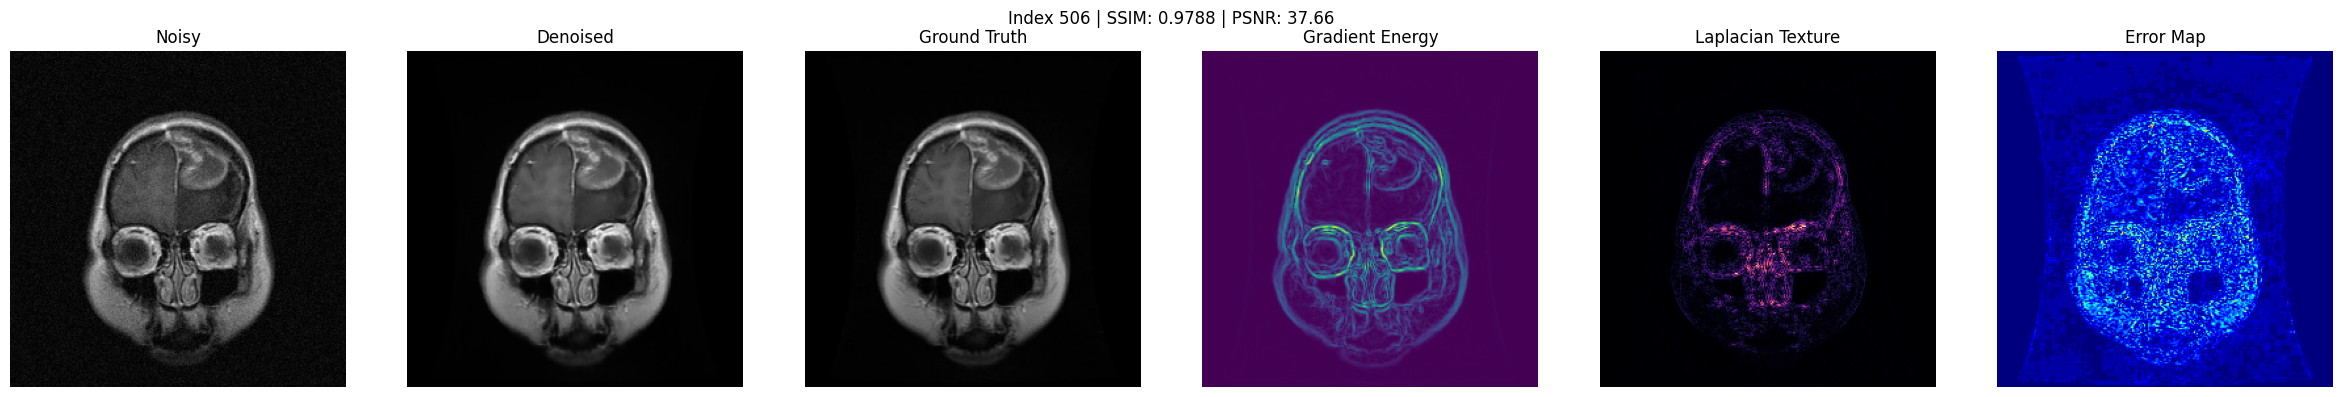

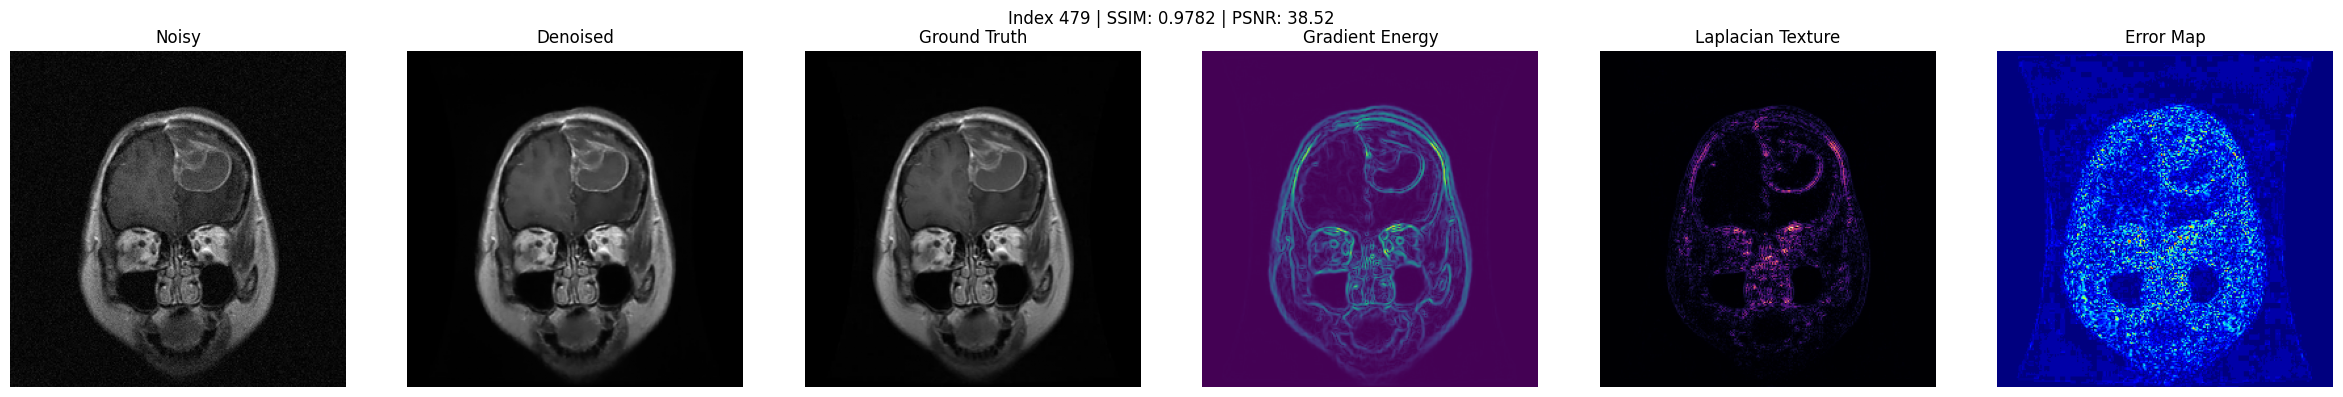

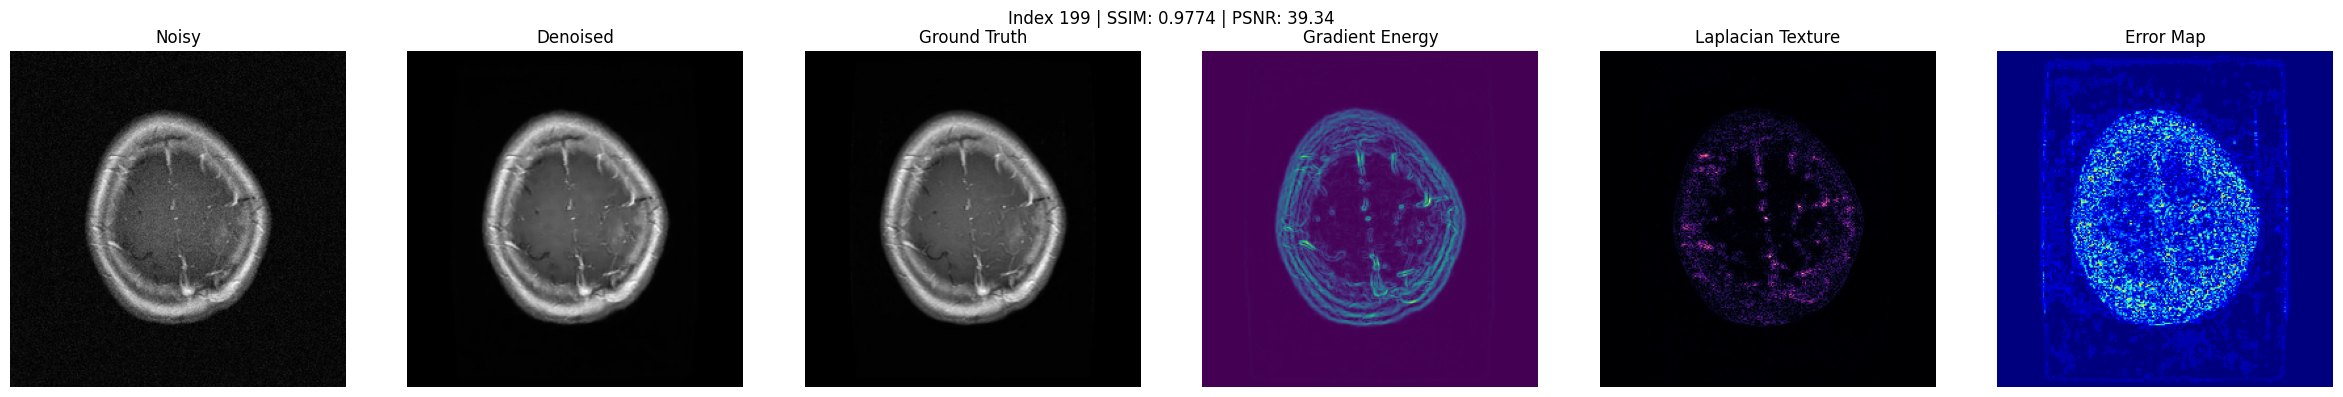

In [ ]:
# ===========================
#  Cell: Advanced Structural & Error Map Visualization (Progress Bar Version)
# Rician DualStage VAE-GAN (No DWT, σ=0.03)
# ===========================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from tqdm import tqdm

# --- Directories ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03"
DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_images")
NOISY_DIR = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_dwt_rician_0.03"
CLEAN_DIR = "/content/drive/MyDrive/Final RI/glioma"
METRICS_CSV = os.path.join(OUTPUT_DIR, "metrics_without_dwt_rician_0.03.csv")

# --- Load metrics ---
metrics_df = pd.read_csv(METRICS_CSV)
top_indices = metrics_df.sort_values("SSIM", ascending=False).head(3).index.tolist()

# --- Helper functions ---
def gradient_energy_map(img):
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobelx**2 + sobely**2)
    return (grad_mag - grad_mag.min()) / (grad_mag.max() - grad_mag.min() + 1e-8)

def laplacian_texture_map(img):
    lap = cv2.Laplacian(img, cv2.CV_64F)
    lap = np.abs(lap)
    return (lap - lap.min()) / (lap.max() - lap.min() + 1e-8)

def error_map(denoised, clean):
    err = np.abs(clean - denoised)
    return (err - err.min()) / (err.max() - err.min() + 1e-8)

# --- Collect visualizations for top-3 only ---
top_visuals = {}

all_noisy_files = sorted(os.listdir(NOISY_DIR))

# --- Main loop with progress bar ---
for idx in tqdm(metrics_df.index, desc="Processing images", ncols=100):
    base_name = all_noisy_files[idx] if idx < len(all_noisy_files) else f"img_{idx:03d}.png"

    noisy_path = os.path.join(NOISY_DIR, base_name)
    clean_path = os.path.join(CLEAN_DIR, base_name)
    denoised_path = os.path.join(DENOISED_DIR, f"denoised_{idx:03d}.png")

    if not (os.path.exists(noisy_path) and os.path.exists(clean_path) and os.path.exists(denoised_path)):
        continue

    # --- Read & normalize ---
    noisy = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE) / 255.0
    clean = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE) / 255.0
    denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE) / 255.0

    noisy = cv2.resize(noisy, (256, 256))
    clean = cv2.resize(clean, (256, 256))
    denoised = cv2.resize(denoised, (256, 256))

    # --- Maps ---
    grad_map = gradient_energy_map(denoised)
    lap_map  = laplacian_texture_map(denoised)
    err_map  = error_map(denoised, clean)

    # --- Store only Top-3 SSIM figures ---
    if idx in top_indices:
        fig, axes = plt.subplots(1, 6, figsize=(24, 4))

        axes[0].imshow(noisy, cmap='gray'); axes[0].set_title("Noisy"); axes[0].axis('off')
        axes[1].imshow(denoised, cmap='gray'); axes[1].set_title("Denoised"); axes[1].axis('off')
        axes[2].imshow(clean, cmap='gray'); axes[2].set_title("Ground Truth"); axes[2].axis('off')
        axes[3].imshow(grad_map, cmap='viridis'); axes[3].set_title("Gradient Energy"); axes[3].axis('off')
        axes[4].imshow(lap_map, cmap='magma'); axes[4].set_title("Laplacian Texture"); axes[4].axis('off')
        axes[5].imshow(err_map, cmap='jet'); axes[5].set_title("Error Map"); axes[5].axis('off')

        ssim_val = metrics_df.loc[idx, "SSIM"]
        psnr_val = metrics_df.loc[idx, "PSNR"]

        plt.suptitle(
            f"Index {idx} | SSIM: {ssim_val:.4f} | PSNR: {psnr_val:.2f}",
            fontsize=12
        )
        plt.tight_layout()
        top_visuals[idx] = fig

# --- Display Top-3 ---
print("\n Displaying Top-3 SSIM Samples\n")

for idx in top_indices:
    display(top_visuals[idx])
    plt.close(top_visuals[idx])


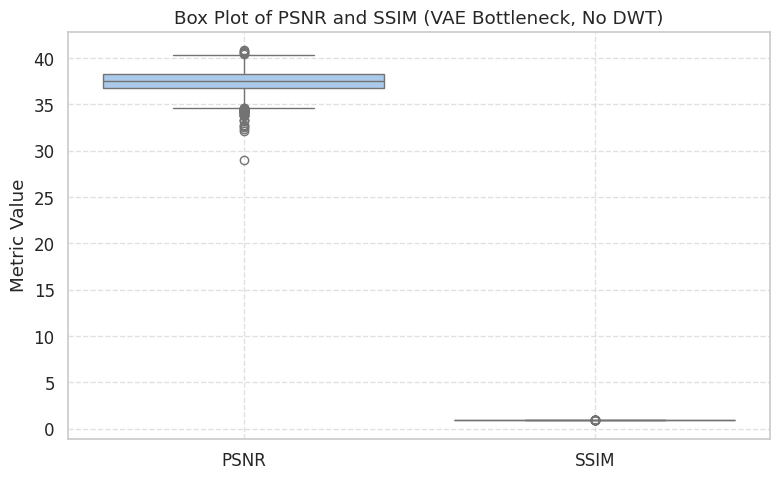

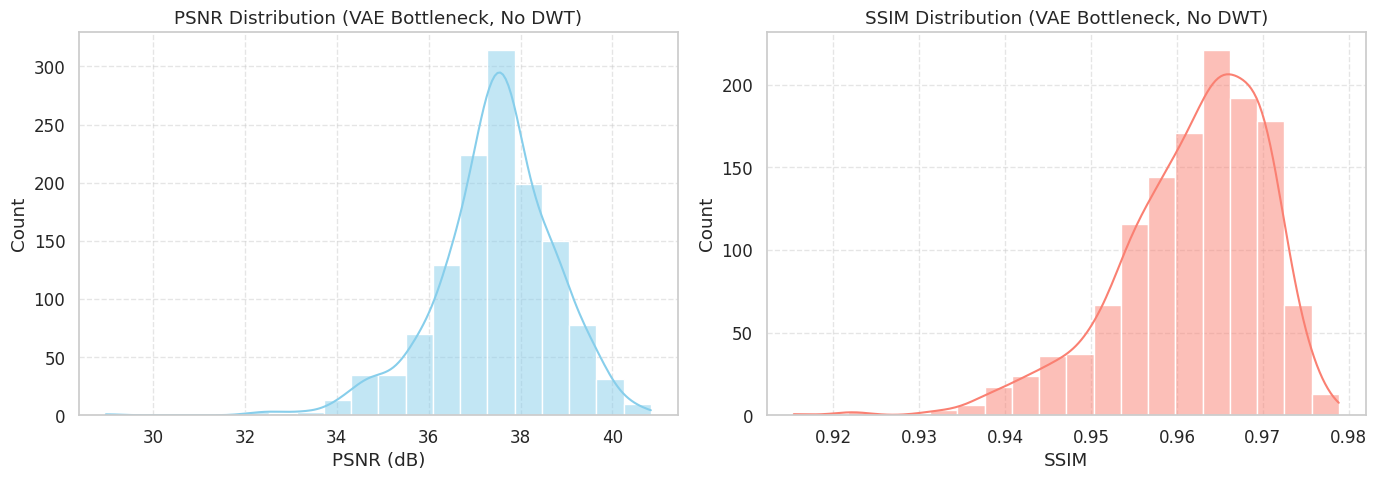

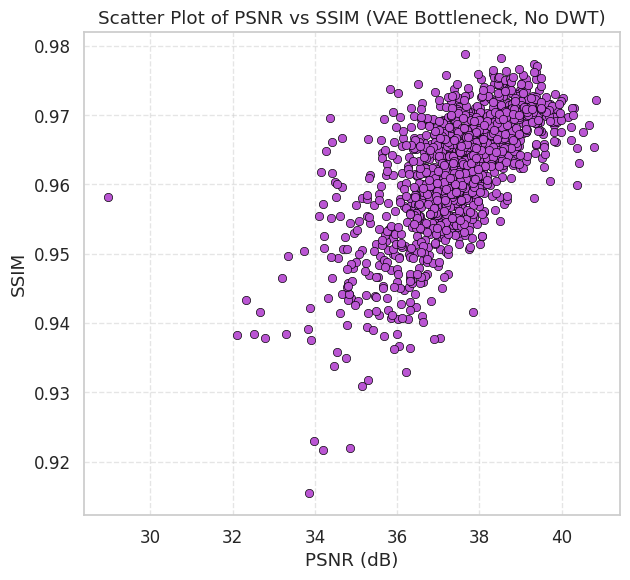


📊 Summary Statistics (VAE Bottleneck, No DWT):


,PSNR,SSIM
mean,37.457271,0.961789
median,37.523122,0.963330
std,1.283511,0.008631


In [ ]:
# ===========================
#  Cell 8: PSNR/SSIM Visualization and Statistical Summary – VAE Bottleneck, Rician-only (No DWT)
# ===========================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create output directory for visualizations ---
CLINICAL_DIR = os.path.join(OUTPUT_DIR, "clinical_panels_vae_no_dwt")
os.makedirs(CLINICAL_DIR, exist_ok=True)

# --- Load evaluation metrics from VAE run ---
df = pd.read_csv(os.path.join(OUTPUT_DIR, "metrics_without_dwt_rician_0.03.csv"))

# --- Seaborn style ---
sns.set(style="whitegrid", font_scale=1.1)

# --- Boxplot for PSNR and SSIM ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[["PSNR", "SSIM"]], palette="pastel")
plt.title("Box Plot of PSNR and SSIM (VAE Bottleneck, No DWT)")
plt.ylabel("Metric Value")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(CLINICAL_DIR, "boxplot_psnr_ssim_vae_no_dwt.png"))
plt.show()

# --- Histograms with KDE for PSNR and SSIM ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["PSNR"], bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title("PSNR Distribution (VAE Bottleneck, No DWT)")
axes[0].set_xlabel("PSNR (dB)")
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(df["SSIM"], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title("SSIM Distribution (VAE Bottleneck, No DWT)")
axes[1].set_xlabel("SSIM")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(CLINICAL_DIR, "histograms_psnr_ssim_vae_no_dwt.png"))
plt.show()

# --- Scatter Plot: PSNR vs SSIM ---
plt.figure(figsize=(6.5, 6))
sns.scatterplot(x="PSNR", y="SSIM", data=df, color='mediumorchid', edgecolor='black')
plt.title("Scatter Plot of PSNR vs SSIM (VAE Bottleneck, No DWT)")
plt.xlabel("PSNR (dB)")
plt.ylabel("SSIM")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(CLINICAL_DIR, "scatter_psnr_vs_ssim_vae_no_dwt.png"))
plt.show()

# --- Summary Statistics ---
summary_stats = df[["PSNR", "SSIM"]].agg(['mean', 'median', 'std'])
summary_stats.to_csv(os.path.join(CLINICAL_DIR, "summary_statistics_vae_no_dwt.csv"))

# --- Display Summary Statistics ---
print("\n Summary Statistics (VAE Bottleneck, No DWT):")
display(summary_stats.round(6))  # Works in Colab/Jupyter

In [ ]:
# ===========================
#  Runtime Restore (Rician-Only, without DWT, σ=0.03)
# ===========================

import torch
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import os, glob

# --- Reload Generator Definition (VAE-integrated U-Net) ---
# This definition should match the one used for training (Cell 3)
class UNetGenerator(torch.nn.Module):
    def __init__(self, in_channels=1, out_channels=1, latent_dim=256):
        super(UNetGenerator, self).__init__()

        # --- Convolutional block with Instance Normalization and LeakyReLU activation ---
        def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1):
            return torch.nn.Sequential(
                torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
                torch.nn.InstanceNorm2d(out_channels),
                torch.nn.LeakyReLU(0.2, inplace=True)
            )

        # --- Encoder ---
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.pool = torch.nn.MaxPool2d(2)

        # --- Bottleneck ---
        self.flatten = torch.nn.Flatten()
        # Calculate the input features for the linear layers dynamically
        # Assuming input image size is 256x256, after 4 pooling layers (factor of 16), size is 16x16
        # Number of channels after enc4 is 512
        fc_input_features = 512 * 16 * 16 # Based on 256x256 input and 4 maxpools

        self.fc_mu = torch.nn.Linear(fc_input_features, latent_dim)
        self.fc_logvar = torch.nn.Linear(fc_input_features, latent_dim)
        self.fc_decoder = torch.nn.Linear(latent_dim, fc_input_features) # Map back to the flattened size
        self.unflatten = torch.nn.Unflatten(1, (512, 16, 16))

        # --- Decoder ---
        self.up1 = torch.nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec1 = conv_block(512, 256)

        self.up2 = torch.nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)

        self.up3 = torch.nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = conv_block(128, 64)

        self.out_conv = torch.nn.Conv2d(64, out_channels, kernel_size=1)


    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # --- Encoder ---
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        e4_pool = self.pool(e4)

        # --- Latent space ---
        flat = self.flatten(e4_pool)
        mu = self.fc_mu(flat)
        logvar = self.fc_logvar(flat)

        #  NaN and overflow protection (inherited from training cell)
        mu = torch.nan_to_num(mu, nan=0.0)
        logvar = torch.nan_to_num(logvar, nan=0.0)
        logvar = torch.clamp(logvar, min=-20.0, max=20.0)

        z = self.reparameterize(mu, logvar)
        z = self.unflatten(self.fc_decoder(z))
        # Ensure z has the expected spatial dimensions after unflatten and before upsampling
        # It should match the spatial dimensions of e4 after pooling, which is 16x16 for 256x256 input
        # The upsampling step should then align it for concatenation with e3
        z = F.interpolate(z, size=e3.shape[2:], mode='bilinear', align_corners=False)


        # --- Decoder ---
        d1 = self.up1(e4) # Up from e4, not z
        d1 = self.dec1(torch.cat([d1, e3], dim=1))

        d2 = self.up2(d1)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d3 = self.up3(d2)
        d3 = self.dec3(torch.cat([d3, e1], dim=1))

        out = torch.sigmoid(self.out_conv(d3))

        #  Protect against NaNs in output (inherited from training cell)
        if torch.isnan(out).any():
            print(" Generator output contains NaN – replacing with zeros")
            out = torch.zeros_like(out)

        # The runtime restore cell was only loading the generator,
        # and the subsequent cells only used the generator output.
        # Therefore, we will only return the output image from the forward pass.
        return out


# --- Reload Best Generator Weights ---
SAVE_PATH = "/content/drive/MyDrive/Final RI/checkpoints/without_dwt_rician_0.03"
best_model_path = max(glob.glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
G = UNetGenerator().cuda()
G.load_state_dict(torch.load(best_model_path))
G.eval()
print(f" Loaded best generator (without DWT, Rician 0.03): {os.path.basename(best_model_path)}")

# --- Redefine Dataset Class ---
class MRIDenoisingDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, transform=None):
        noisy_all = sorted(glob.glob(os.path.join(noisy_dir, "*.*")))
        clean_all = sorted(glob.glob(os.path.join(clean_dir, "*.*")))
        noisy_dict = {os.path.basename(p): p for p in noisy_all}
        clean_dict = {os.path.basename(p): p for p in clean_all}
        common = sorted(set(noisy_dict.keys()) & set(clean_dict.keys()))
        self.noisy = [noisy_dict[f] for f in common]
        self.clean = [clean_dict[f] for f in common]
        self.transform = transform

    def __len__(self):
        return len(self.noisy)

    def __getitem__(self, idx):
        noisy = cv2.imread(self.noisy[idx], cv2.IMREAD_GRAYSCALE)
        clean = cv2.imread(self.clean[idx], cv2.IMREAD_GRAYSCALE)
        noisy = cv2.resize(noisy, (256, 256)).astype(np.float32) / 255.0
        clean = cv2.resize(clean, (256, 256)).astype(np.float32) / 255.0
        if self.transform:
            noisy = self.transform(noisy)
            clean = self.transform(clean)
        return noisy, clean

# --- Load val_loader (without DWT, Rician 0.03 paths) ---
transform = transforms.ToTensor()
val_loader = DataLoader(
    MRIDenoisingDataset(
        "/content/drive/MyDrive/Final RI/single_noise_outputs/without_dwt_rician_0.03", # Corrected path
        "/content/drive/MyDrive/Final RI/glioma",
        transform
    ),
    batch_size=1, shuffle=False
)

# --- Reload Top-10 SSIM indices from metrics for this run ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03"
metrics_df = pd.read_csv(os.path.join(OUTPUT_DIR, "metrics_without_dwt_rician_0.03.csv"))
selected_samples = metrics_df.sort_values("SSIM", ascending=False).head(10)["index"].tolist()
print(" Selected Top 10 Samples (by SSIM, without DWT, Rician 0.03):", selected_samples)

✅ Loaded best generator (without DWT, Rician 0.03): best_generator_epoch30_ssim0.9618.pt
📊 Selected Top 10 Samples (by SSIM, without DWT, Rician 0.03): [506, 479, 199, 744, 1155, 522, 792, 737, 790, 570]


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from IPython.display import Image, display

# --- Load metrics for without DWT, Rician σ=0.03 ---
metrics_df = pd.read_csv("/content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03/metrics_without_dwt_rician_0.03.csv")

# --- Load the noise log to get original filenames ---
NOISY_DIR = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_dwt_rician_0.03"
csv_path = os.path.join(NOISY_DIR, "noise_log.csv")
log_df = pd.read_csv(csv_path)

# --- Top 10 SSIM samples ---
top_indices = metrics_df.sort_values("SSIM", ascending=False).head(10)["index"].tolist()

# --- Set paths (without DWT, Rician σ=0.03 dirs) ---
denoised_dir = "/content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03/denoised_images"
noisy_dir    = NOISY_DIR
clean_dir    = "/content/drive/MyDrive/Final RI/glioma"
save_dir     = "/content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03/visualization_panels"

# --- Create output folder if it doesn't exist ---
os.makedirs(save_dir, exist_ok=True)

# --- Helper functions ---
def compute_edge_diff(img1, img2):
    """Compute mean absolute edge map difference using Sobel."""
    sobelx1 = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
    sobely1 = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)
    edges1 = np.sqrt(sobelx1**2 + sobely1**2)

    sobelx2 = cv2.Sobel(img2, cv2.CV_64F, 1, 0, ksize=3)
    sobely2 = cv2.Sobel(img2, cv2.CV_64F, 0, 1, ksize=3)
    edges2 = np.sqrt(sobelx2**2 + sobely2**2)

    return np.mean(np.abs(edges1 - edges2))

def compute_laplacian_diff(img1, img2):
    """Compute difference in average Laplacian variance (sharpness)."""
    lap1 = cv2.Laplacian(img1, cv2.CV_64F).var()
    lap2 = cv2.Laplacian(img2, cv2.CV_64F).var()
    return abs(lap1 - lap2)

# --- Create single figure: 10 rows × 3 columns ---
fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(12, 40))
fig.subplots_adjust(hspace=0.6)

for row_idx, sample_idx in enumerate(top_indices):
    try:
        original_filename = log_df.loc[sample_idx, "filename"]
    except KeyError:
        print(f" Warning: Filename for index {sample_idx} not found. Skipping.")
        continue

    noisy_path    = os.path.join(noisy_dir, original_filename)
    clean_path    = os.path.join(clean_dir, original_filename)
    denoised_path = os.path.join(denoised_dir, f"denoised_{sample_idx:03d}.png")

    # Read images
    noisy    = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
    clean    = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)
    denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE)

    if noisy is None or clean is None or denoised is None:
        print(f" Skipping {sample_idx}, missing image(s).")
        continue

    # Resize and normalize
    noisy    = cv2.resize(noisy, (256, 256)) / 255.0
    clean    = cv2.resize(clean, (256, 256)) / 255.0
    denoised = cv2.resize(denoised, (256, 256)) / 255.0

    # --- Compute extra metrics ---
    edge_diff = compute_edge_diff(clean, denoised)
    lap_diff  = compute_laplacian_diff(clean, denoised)

    # --- Plot images ---
    axes[row_idx, 0].imshow(noisy, cmap='gray')
    axes[row_idx, 0].set_title(f" Noisy\nIdx: {sample_idx}")
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(denoised, cmap='gray')
    axes[row_idx, 1].set_title(" Denoised")
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(clean, cmap='gray')
    axes[row_idx, 2].set_title(" Ground Truth")
    axes[row_idx, 2].axis('off')

    # --- Add all metrics below row ---
    ssim = metrics_df.loc[sample_idx, "SSIM"]
    psnr = metrics_df.loc[sample_idx, "PSNR"]

    metrics_text = f"SSIM: {ssim:.4f} | PSNR: {psnr:.2f} dB\nEdgeDiff: {edge_diff:.4f} | LapDiff: {lap_diff:.4f}"
    axes[row_idx, 1].text(0.5, -0.25, metrics_text,
                          fontsize=9, ha='center', va='top', transform=axes[row_idx, 1].transAxes)

# --- Save full grid as one image ---
final_path = os.path.join(save_dir, "top10_visualization_without_dwt_edges_laplacian.png")
plt.tight_layout()
plt.savefig(final_path, dpi=150)
plt.close()

print(f" Saved full visualization with Edge/Laplacian (without DWT, Rician σ=0.03): {final_path}")
display(Image(filename=final_path))


Output hidden; open in https://colab.research.google.com to view.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


✅ Saved: /content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03/visualization_panels/top10_visualization_without_dwt_edges_laplacian.png


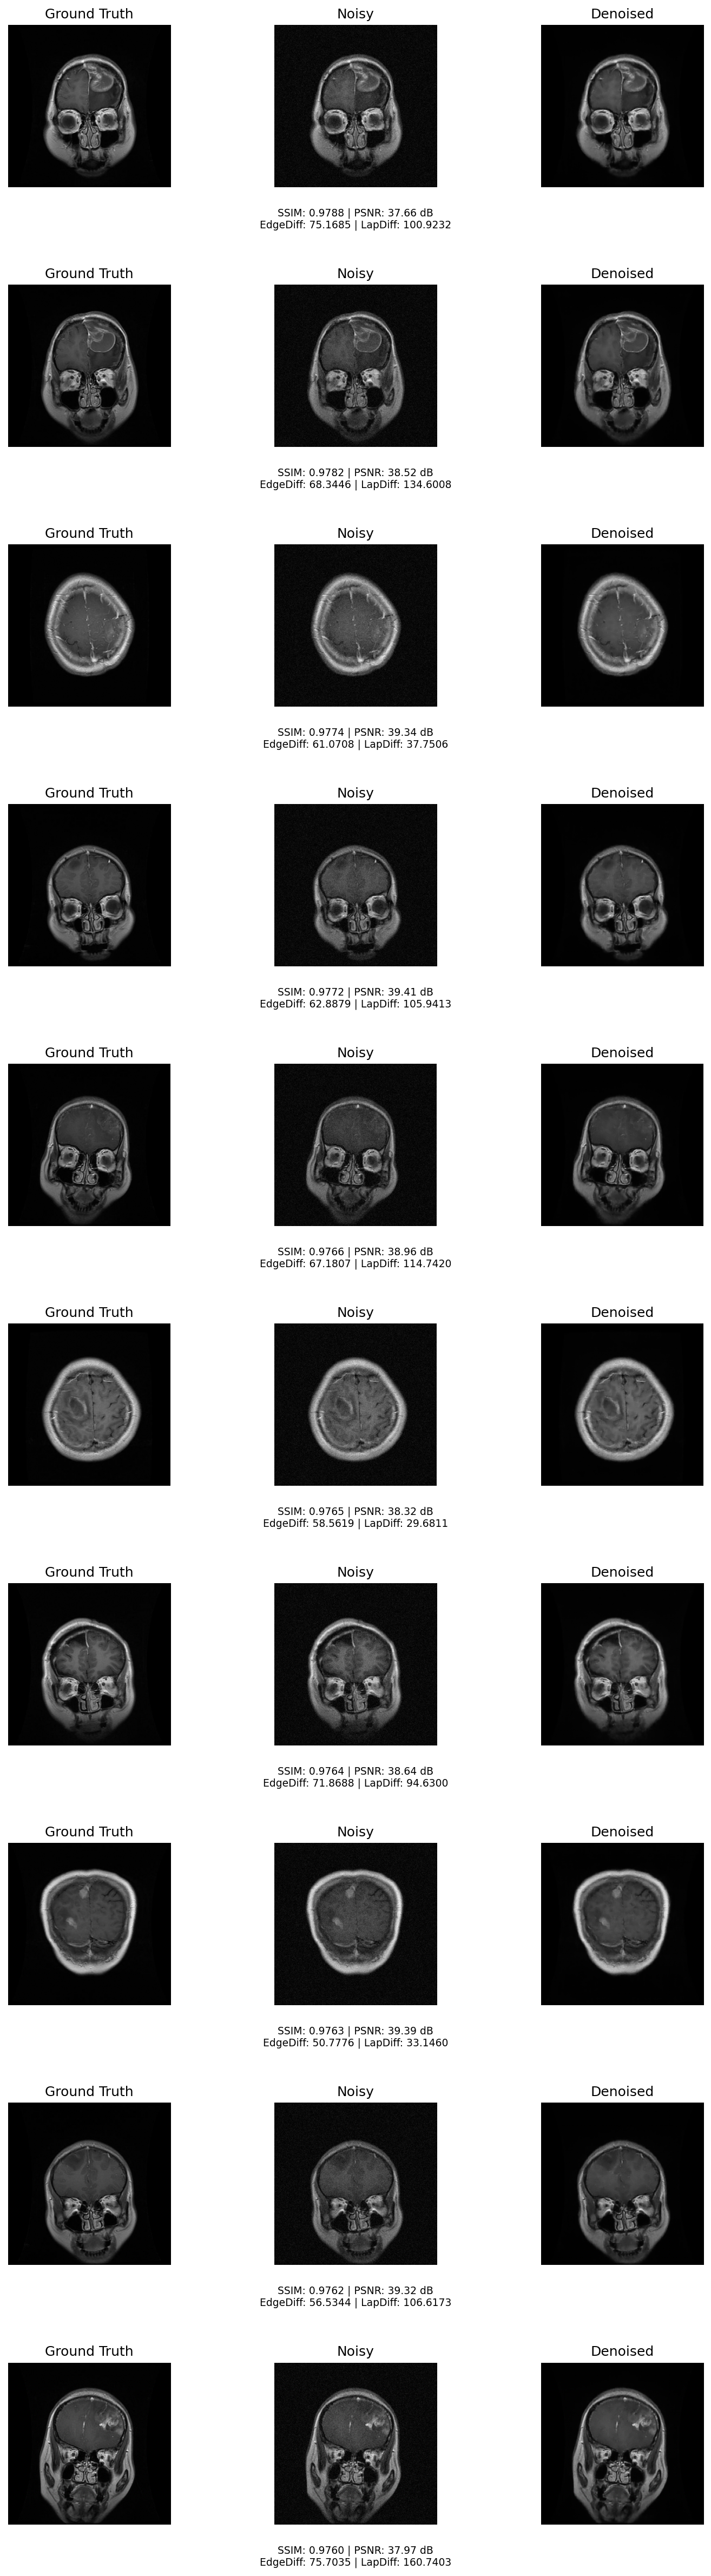

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from IPython.display import Image, display

# =========================
# Load metrics
# =========================
metrics_df = pd.read_csv(
    "/content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03/metrics_without_dwt_rician_0.03.csv"
)

# =========================
# Load noise log
# =========================
NOISY_DIR = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_dwt_rician_0.03"
csv_path = os.path.join(NOISY_DIR, "noise_log.csv")
log_df = pd.read_csv(csv_path)

# =========================
# Top 10 SSIM samples
# =========================
top_indices = (
    metrics_df.sort_values("SSIM", ascending=False)
    .head(10)["index"]
    .tolist()
)

# =========================
# Paths
# =========================
denoised_dir = "/content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03/denoised_images"
noisy_dir    = NOISY_DIR
clean_dir    = "/content/drive/MyDrive/Final RI/glioma"
save_dir     = "/content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03/visualization_panels"

os.makedirs(save_dir, exist_ok=True)

# =========================
# Load image (NO modification)
# =========================
def load_image(path):
    if not os.path.exists(path):
        print("File not found:", path)
        return None

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Could not load:", path)
        return None

    return img


# =========================
# Healthcare-safe size match
# Center crop to common region
# =========================
def match_size_for_metrics(img1, img2):

    h1, w1 = img1.shape
    h2, w2 = img2.shape

    target_h = min(h1, h2)
    target_w = min(w1, w2)

    def center_crop(img, th, tw):
        h, w = img.shape
        start_h = (h - th) // 2
        start_w = (w - tw) // 2
        return img[start_h:start_h+th, start_w:start_w+tw]

    return center_crop(img1, target_h, target_w), center_crop(img2, target_h, target_w)


# =========================
# Metric helpers
# =========================
def compute_edge_diff(img1, img2):

    img1, img2 = match_size_for_metrics(img1, img2)

    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    sobelx1 = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
    sobely1 = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)
    edges1 = np.sqrt(sobelx1**2 + sobely1**2)

    sobelx2 = cv2.Sobel(img2, cv2.CV_64F, 1, 0, ksize=3)
    sobely2 = cv2.Sobel(img2, cv2.CV_64F, 0, 1, ksize=3)
    edges2 = np.sqrt(sobelx2**2 + sobely2**2)

    return np.mean(np.abs(edges1 - edges2))


def compute_laplacian_diff(img1, img2):

    img1, img2 = match_size_for_metrics(img1, img2)

    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    lap1 = cv2.Laplacian(img1, cv2.CV_64F).var()
    lap2 = cv2.Laplacian(img2, cv2.CV_64F).var()

    return abs(lap1 - lap2)


# =========================
# Create visualization panel
# =========================
fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(12, 40))
plt.subplots_adjust(hspace=0.6, wspace=0.2)

for row_idx, sample_idx in enumerate(top_indices):

    if sample_idx not in log_df.index:
        print(f" Filename for index {sample_idx} not found.")
        continue

    original_filename = log_df.loc[sample_idx, "filename"]

    noisy_path    = os.path.join(noisy_dir, original_filename)
    clean_path    = os.path.join(clean_dir, original_filename)
    denoised_path = os.path.join(denoised_dir, f"denoised_{sample_idx:03d}.png")

    noisy    = load_image(noisy_path)
    clean    = load_image(clean_path)
    denoised = load_image(denoised_path)

    if noisy is None or clean is None or denoised is None:
        print(f" Skipping {sample_idx}, missing image(s).")
        continue

    # --- Compute metrics safely ---
    edge_diff = compute_edge_diff(clean, denoised)
    lap_diff  = compute_laplacian_diff(clean, denoised)

    # --- Plot images exactly as stored ---
    images = [clean, noisy, denoised]
    titles = ["Ground Truth", "Noisy", "Denoised"]

    for col in range(3):
        axes[row_idx, col].axis("off")
        axes[row_idx, col].imshow(images[col], cmap="gray", vmin=0, vmax=255)
        axes[row_idx, col].set_title(titles[col], fontsize=12)

    # --- Metrics ---
    ssim = metrics_df.loc[sample_idx, "SSIM"]
    psnr = metrics_df.loc[sample_idx, "PSNR"]

    metrics_text = (
        f"SSIM: {ssim:.4f} | PSNR: {psnr:.2f} dB\n"
        f"EdgeDiff: {edge_diff:.4f} | LapDiff: {lap_diff:.4f}"
    )

    axes[row_idx, 1].text(
        0.5, -0.25,
        metrics_text,
        fontsize=9,
        ha="center",
        transform=axes[row_idx, 1].transAxes
    )

# =========================
# Save + display
# =========================
final_path = os.path.join(
    save_dir,
    "top10_visualization_without_dwt_edges_laplacian.png"
)

plt.savefig(final_path, bbox_inches="tight", dpi=150)
plt.close()

print(" Saved:", final_path)
display(Image(filename=final_path))

Processing images: 100%|████████████████████████████████████████| 1297/1297 [46:25<00:00,  2.15s/it]



✅ Displaying Top-3 SSIM Samples



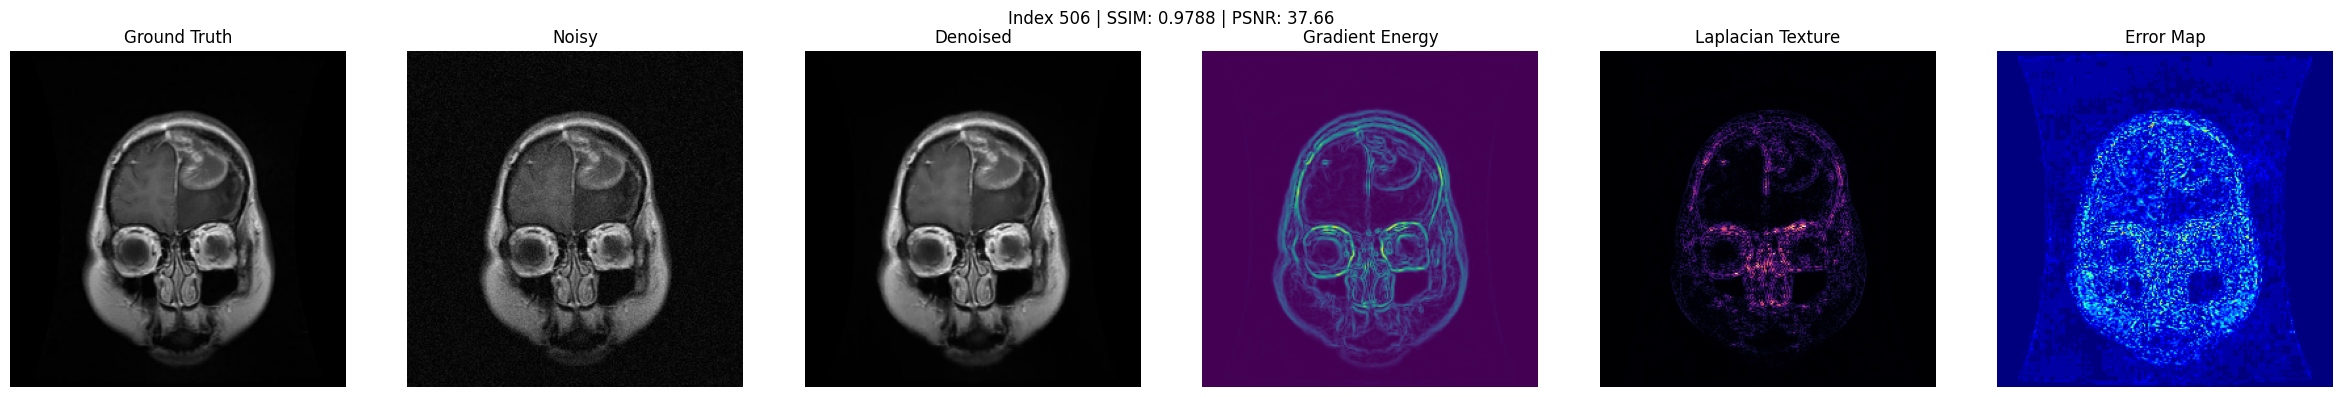

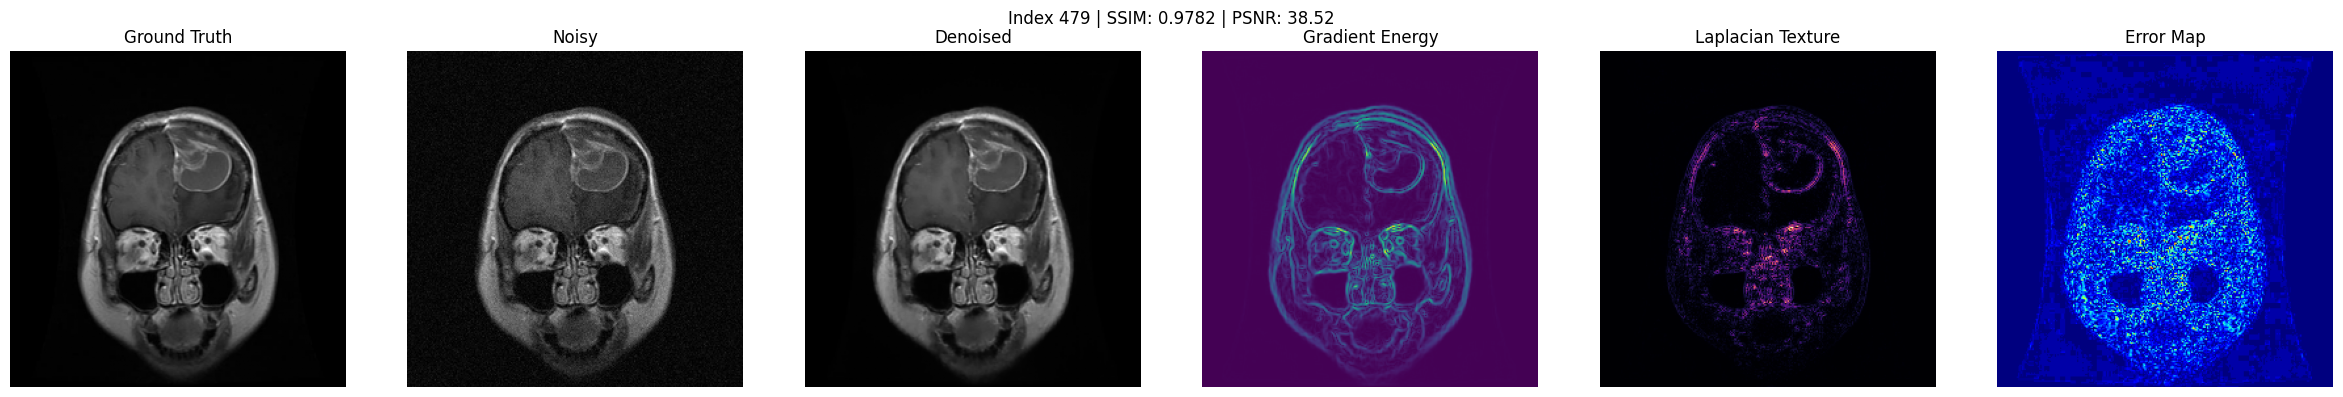

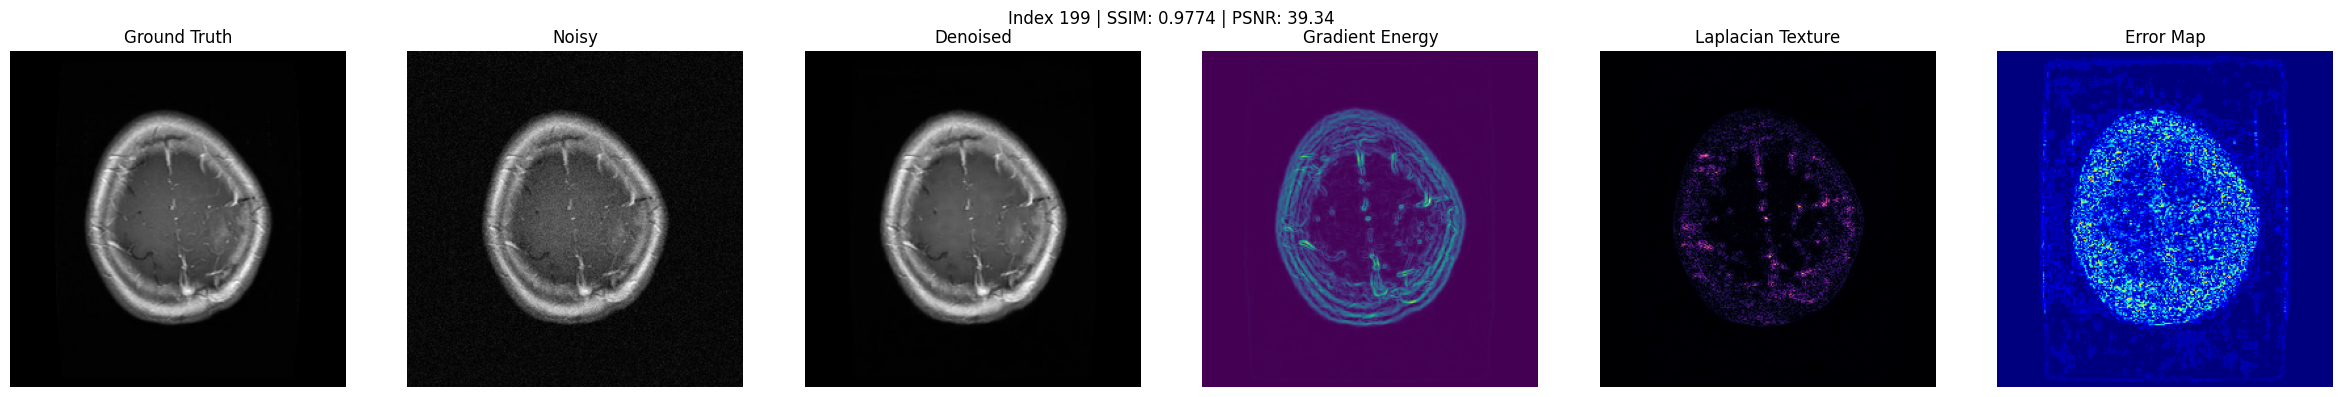

In [2]:
# ===========================
#  Cell: Advanced Structural & Error Map Visualization (Progress Bar Version)
# Rician DualStage VAE-GAN (No DWT, σ=0.03)
# ===========================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from tqdm import tqdm

# --- Directories ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/without_dwt_rician_0.03"
DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_images")
NOISY_DIR = "/content/drive/MyDrive/Final RI/single_noise_outputs/without_dwt_rician_0.03"
CLEAN_DIR = "/content/drive/MyDrive/Final RI/glioma"
METRICS_CSV = os.path.join(OUTPUT_DIR, "metrics_without_dwt_rician_0.03.csv")

# --- Load metrics ---
metrics_df = pd.read_csv(METRICS_CSV)
top_indices = metrics_df.sort_values("SSIM", ascending=False).head(3).index.tolist()

# --- Load noise log for robust filename mapping ---
log_df = pd.read_csv(os.path.join(NOISY_DIR, "noise_log.csv"))

# --- Helper functions ---
def gradient_energy_map(img):
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobelx**2 + sobely**2)
    return (grad_mag - grad_mag.min()) / (grad_mag.max() - grad_mag.min() + 1e-8)

def laplacian_texture_map(img):
    lap = cv2.Laplacian(img, cv2.CV_64F)
    lap = np.abs(lap)
    return (lap - lap.min()) / (lap.max() - lap.min() + 1e-8)

def error_map(denoised, clean):
    err = np.abs(clean - denoised)
    return (err - err.min()) / (err.max() - err.min() + 1e-8)

# --- Collect visualizations for top-3 only ---
top_visuals = {}

# all_noisy_files is no longer strictly needed if using log_df
# all_noisy_files = sorted(os.listdir(NOISY_DIR))

# --- Main loop with progress bar ---
for idx in tqdm(metrics_df.index, desc="Processing images", ncols=100):
    # Retrieve filename using the robust log_df mapping
    try:
        base_name = log_df.loc[idx, "filename"]
    except KeyError:
        # If the index is not found in log_df (shouldn't happen if log_df is complete)
        print(f" Skipping index {idx}: filename not found in log_df.")
        continue

    noisy_path = os.path.join(NOISY_DIR, base_name)
    clean_path = os.path.join(CLEAN_DIR, base_name)
    denoised_path = os.path.join(DENOISED_DIR, f"denoised_{idx:03d}.png")

    if not (os.path.exists(noisy_path) and os.path.exists(clean_path) and os.path.exists(denoised_path)):
        print(f" Skipping index {idx}: one or more files missing for {base_name}. Noisy: {os.path.exists(noisy_path)}, Clean: {os.path.exists(clean_path)}, Denoised: {os.path.exists(denoised_path)}")
        continue

    # --- Read & normalize ---
    noisy = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE) / 255.0
    clean = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE) / 255.0
    denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE) / 255.0

    noisy = cv2.resize(noisy, (256, 256))
    clean = cv2.resize(clean, (256, 256))
    denoised = cv2.resize(denoised, (256, 256))

    # --- Maps ---
    grad_map = gradient_energy_map(denoised)
    lap_map  = laplacian_texture_map(denoised)
    err_map  = error_map(denoised, clean)

    # --- Store only Top-3 SSIM figures ---
    if idx in top_indices:
        fig, axes = plt.subplots(1, 6, figsize=(24, 4))

        #  ORDER CHANGED ONLY HERE
        axes[0].imshow(clean, cmap='gray'); axes[0].set_title("Ground Truth"); axes[0].axis('off')
        axes[1].imshow(noisy, cmap='gray'); axes[1].set_title("Noisy"); axes[1].axis('off')
        axes[2].imshow(denoised, cmap='gray'); axes[2].set_title("Denoised"); axes[2].axis('off')

        axes[3].imshow(grad_map, cmap='viridis'); axes[3].set_title("Gradient Energy"); axes[3].axis('off')
        axes[4].imshow(lap_map, cmap='magma'); axes[4].set_title("Laplacian Texture"); axes[4].axis('off')
        axes[5].imshow(err_map, cmap='jet'); axes[5].set_title("Error Map"); axes[5].axis('off')

        ssim_val = metrics_df.loc[idx, "SSIM"]
        psnr_val = metrics_df.loc[idx, "PSNR"]

        plt.suptitle(
            f"Index {idx} | SSIM: {ssim_val:.4f} | PSNR: {psnr_val:.2f}",
            fontsize=12
        )
        plt.tight_layout()
        top_visuals[idx] = fig

# --- Display Top-3 ---
print("\n Displaying Top-3 SSIM Samples\n")

for idx in top_indices:
    if idx in top_visuals:
        display(top_visuals[idx])
        plt.close(top_visuals[idx])
    else:
        print(f" Visualization for index {idx} not generated (possibly due to missing files).")